![jupyter](img/logoItq.png)

**Nombre:** *Adrián Falcones*

**Primer Modulo**

![jupyter](img/logoPy.png)

Image dimensions:  (256, 256, 3)


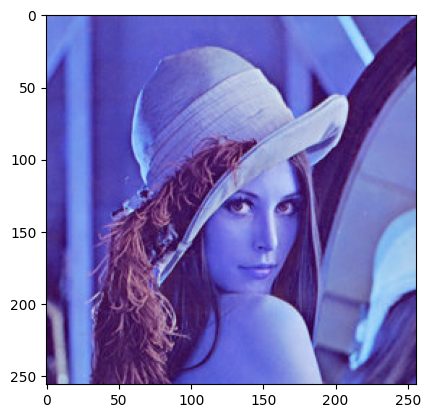

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))

plt.imshow(img, cmap='gray')
plt.show()

In [2]:
R = img[:, :, 2]
G = img[:, :, 1]
B = img[:, :, 0]

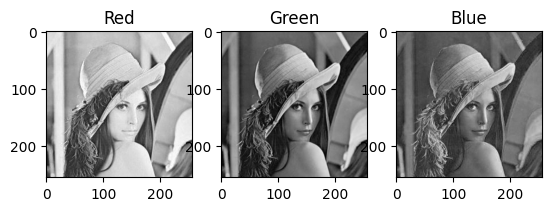

In [3]:
fig, ax = plt.subplots(1, 3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

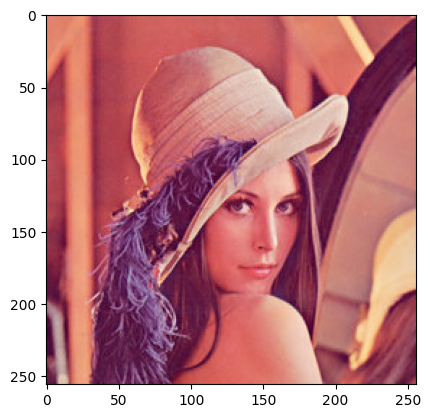

In [4]:
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()

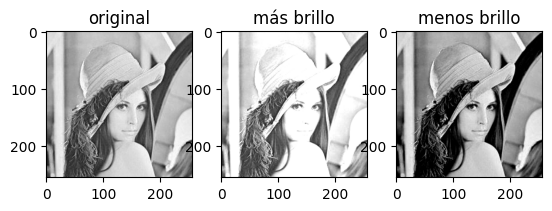

In [5]:
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,2]  # canal rojo

mas_brillo = 50
menos_brillo = -100
mas_brillo_img = cv2.add(img, mas_brillo)
menos_brillo_img = cv2.add(img, menos_brillo)

fig, ax = plt.subplots(1, 3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()

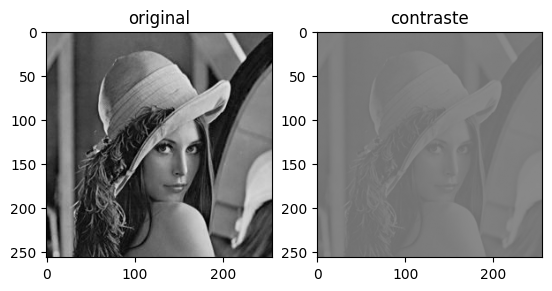

In [6]:
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,1]  # canal verde

contraste = -100
f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)

contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

C:\Users\ESTUDIANTES-ITQ\AppData\Local\Temp\ipykernel_6368\3921753577.py:14: RuntimeWarning: invalid value encountered in cast
  CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')


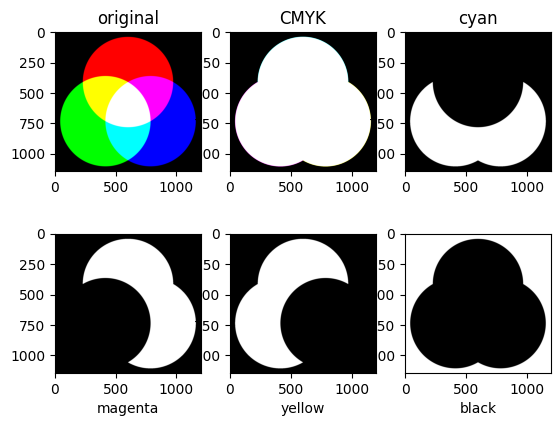

In [8]:
import numpy as np
from skimage import io

img = io.imread('images/colores.png')
rgb = img.copy()
rgb_p = rgb.astype('uint8')/255

with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    C = (1 - rgb_p[:,:,0] - K) / (1 - K)
    M = (1 - rgb_p[:,:,1] - K) / (1 - K)
    Y = (1 - rgb_p[:,:,2] - K) / (1 - K)

CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
C,M,Y,K = cv2.split(CMYK)

fig, ax = plt.subplots(2, 3)
ax[0,0].imshow(img, cmap='gray'), ax[0,0].set_title('original')
ax[0,1].imshow(CMYK.astype('uint8'), cmap='gray'), ax[0,1].set_title('CMYK')
ax[0,2].imshow(C.astype('uint8'), cmap='gray'), ax[0,2].set_title('cyan')
ax[1,0].imshow(M.astype('uint8'), cmap='gray'), ax[1,0].set_xlabel('magenta')
ax[1,1].imshow(Y.astype('uint8'), cmap='gray'), ax[1,1].set_xlabel('yellow')
ax[1,2].imshow(K.astype('uint8'), cmap='gray'), ax[1,2].set_xlabel('black')
plt.show()

In [9]:
img = cv2.imread('images/Lena_RGB.png')

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

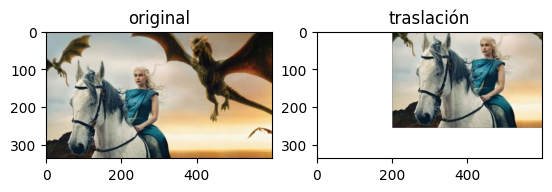

In [30]:
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape

M = np.float32([[1,0,200],[0,1,-80]])
new_img = cv2.warpAffine(img, M, (cols, rows))

figs, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

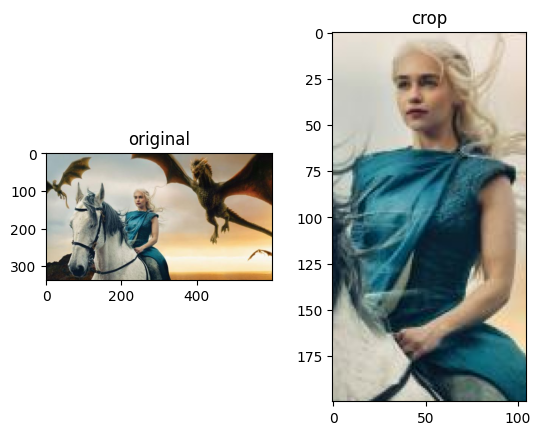

In [11]:
img = io.imread('images/GOT.png')

new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

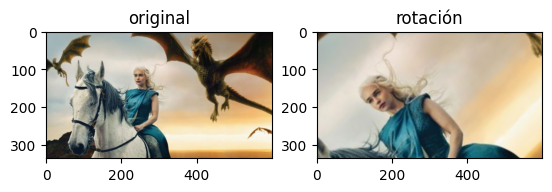

In [12]:
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape

M = cv2.getRotationMatrix2D((cols/2, rows/2), angle=45, scale=2)
new_img = cv2.warpAffine(img, M, (cols, rows))

figs, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()


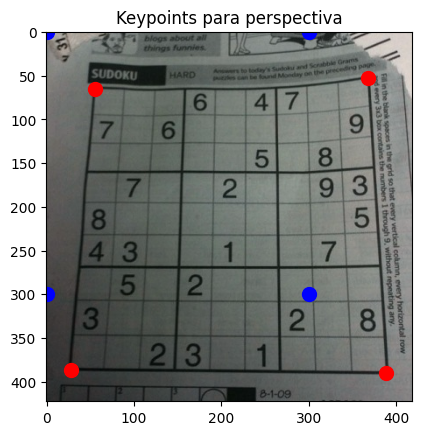

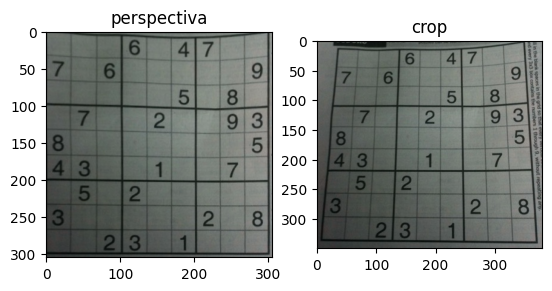

In [13]:
img = cv2.imread('images/sudoku.png')
rows, cols, ch = img.shape

pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)
plt.title('Keypoints para perspectiva')
plt.show()

M = cv2.getPerspectiveTransform(pts1, pts2)
pers = cv2.warpPerspective(img, M, (305,305))
crop = img[50:400, 20:400]

figs, ax = plt.subplots(1, 2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()

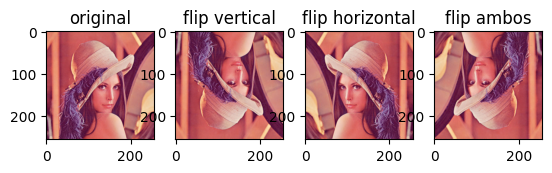

In [14]:
img = cv2.cvtColor(cv2.imread('images/Lena_RGB.png'), cv2.COLOR_BGR2RGB)

flipVertical   = cv2.flip(img, 0)   # 0 = voltear verticalmente (eje X)
flipHorizontal = cv2.flip(img, 1)   # 1 = voltear horizontalmente (eje Y)
flipBoth       = cv2.flip(img, -1)  # -1 = voltear en ambos ejes

figs, ax = plt.subplots(1, 4)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(flipVertical, cmap='gray'), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal, cmap='gray'), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth, cmap='gray'), ax[3].set_title('flip ambos')
plt.show()